# LEDGER — Two-Engine Underwriting · executable walkthrough

**One notebook, both engines, run top-to-bottom.** This is the credit decisioning
core of the LEDGER MVP, made executable for a live demo.

- **Engine A — rules** (`policy/credit_policy.py`): transparent, **makes the decision today**.
- **Engine B — shadow ML** (`models/train_shadow.py`): a gradient-boosting model that
  scores in parallel, is **logged but never used** to decide.

The code below mirrors the repo modules. Data is **synthetic**. `Run ▸ Run All Cells`
executes everything in a few seconds.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss

RNG = 42
np.random.seed(RNG)
pd.set_option("display.precision", 3)
print("Environment ready — numpy", np.__version__, "| pandas", pd.__version__,
      "| scikit-learn", __import__("sklearn").__version__)

## Part 0 · Config — thresholds & product rules

Mirrors `config.py`: 15 scored gates (each with a green and a red threshold and a
direction), the 7 hard knockouts, and the Year-1 product caps. One source of truth.

In [ ]:
# Scored gates:  name -> (green, red, higher_is_worse)   [mirrors config.SCORED_GATES]
GATES = {
    "revenue_volatility_90d":         (0.25, 0.45, True),
    "refund_rate_ltm":                (0.03, 0.08, True),
    "settlement_delay_p95":           (5,    10,   True),
    "chargeback_rate_ltm":            (0.005,0.015,True),
    "platform_concentration":         (0.40, 0.65, True),
    "net_cashflow_coverage":          (1.80, 1.20, False),
    "supplier_pay_punctuality":       (0.90, 0.70, False),
    "ad_spend_ratio_3m":              (0.15, 0.30, True),
    "vat_punctuality":                (0.90, 0.70, False),
    "gross_margin_avg_6m":            (0.35, 0.15, False),
    "revenue_bank_delta_avg":         (0.05, 0.15, True),
    "marketplace_account_health_avg": (8.0,  5.0,  False),
    "marketplace_late_shipment_rate": (0.02, 0.08, True),
    "cancellation_rate_90d":          (0.03, 0.08, True),
    "return_rate_90d":                (0.05, 0.12, True),
}

# Product constants  [mirrors config.py]
YEAR1_CAP       = 25_000
DECLINE_RED     = 3        # >= 3 red gates                  -> DECLINE
REVIEW_RED      = 2        # >= 2 red gates                  -> MANUAL_REVIEW
REVIEW_TOTAL    = 5        # >= 5 (red + amber) gates         -> MANUAL_REVIEW
MIN_TRADING_MO  = 24
MAX_RECON_DELTA = 0.20
MAX_NEG_BAL_PCT = 0.50
MIN_MONTHLY_GMV = 25_000
PRICING = {"A": 0.110, "B": 0.125, "C": 0.140}

print(len(GATES), "scored gates | 7 knockouts | Year-1 cap EUR", f"{YEAR1_CAP:,}")

## Part 1 · The input — a merchant credit passport

Each merchant is a dict of features built from six connected sources (bank/PSD2, PSP,
webshop, marketplace, accounting, KYC). Four merchants to run through both engines —
one clean, one healthy-with-flags, one risky, one that fails KYC.

In [19]:
def merchant(name, **f):
    base = dict(  # sensible green defaults; override per merchant
        revenue_volatility_90d=0.12, refund_rate_ltm=0.02, settlement_delay_p95=3,
        chargeback_rate_ltm=0.002, platform_concentration=0.30, net_cashflow_coverage=4.0,
        supplier_pay_punctuality=0.98, ad_spend_ratio_3m=0.06, vat_punctuality=0.99,
        gross_margin_avg_6m=0.40, revenue_bank_delta_avg=0.01,
        marketplace_account_health_avg=9.0, marketplace_late_shipment_rate=0.01,
        cancellation_rate_90d=0.01, return_rate_90d=0.02,
        days_cash_on_hand=300, monthly_gmv_avg_6m=80_000, trading_months=40,
        kvk_active=True, sanctions_hit=False, ubo_director_match=True,
        bank_psp_recon_delta=0.03, negative_balance_pct_90d=0.0,
        requested_amount=15_000, requested_tenor_months=6, monthly_net_cashflow_avg_6m=18_000,
    )
    base.update(f); base["name"] = name
    return base

MERCHANTS = [
    merchant("Bloom Cosmetics"),  # textbook-clean
    merchant("Volta Electronics", revenue_volatility_90d=0.33, platform_concentration=0.50,
             settlement_delay_p95=7, gross_margin_avg_6m=0.23, net_cashflow_coverage=17.0,
             monthly_gmv_avg_6m=88_000, days_cash_on_hand=527, monthly_net_cashflow_avg_6m=20_000),
    merchant("Tassen & Co",  # 2 red gates -> review, but elevated across the board
             chargeback_rate_ltm=0.020, revenue_volatility_90d=0.50,        # the 2 reds
             refund_rate_ltm=0.05, platform_concentration=0.60, gross_margin_avg_6m=0.25,
             net_cashflow_coverage=1.4, settlement_delay_p95=8, supplier_pay_punctuality=0.78,
             ad_spend_ratio_3m=0.22, vat_punctuality=0.80, revenue_bank_delta_avg=0.10,
             marketplace_account_health_avg=6.5, marketplace_late_shipment_rate=0.05,
             cancellation_rate_90d=0.05, return_rate_90d=0.09,
             days_cash_on_hand=40, monthly_gmv_avg_6m=45_000, trading_months=30,
             monthly_net_cashflow_avg_6m=9_000),
    merchant("QuickFlip BV", ubo_director_match=False,                      # fails KYC -> knockout
             revenue_volatility_90d=0.38, platform_concentration=0.58, chargeback_rate_ltm=0.010,
             refund_rate_ltm=0.06, gross_margin_avg_6m=0.28, settlement_delay_p95=9,
             marketplace_account_health_avg=6.0, return_rate_90d=0.08, cancellation_rate_90d=0.05,
             days_cash_on_hand=60, monthly_gmv_avg_6m=50_000),
]

pd.DataFrame(MERCHANTS).set_index("name")[
    ["revenue_volatility_90d", "net_cashflow_coverage", "chargeback_rate_ltm",
     "platform_concentration", "gross_margin_avg_6m", "monthly_gmv_avg_6m",
     "ubo_director_match"]]

,revenue_volatility_90d,net_cashflow_coverage,chargeback_rate_ltm,platform_concentration,gross_margin_avg_6m,monthly_gmv_avg_6m,ubo_director_match
name,,,,,,,
Bloom Cosmetics,0.12,4.0,0.002,0.30,0.40,80000,True
Volta Electronics,0.33,17.0,0.002,0.50,0.23,88000,True
Tassen & Co,0.50,1.4,0.020,0.60,0.25,45000,True
QuickFlip BV,0.38,4.0,0.010,0.58,0.28,50000,False


## Part 2 · Engine A — the rules engine (decides today)

7 hard knockouts → count green / amber / red gates → **APPROVE / MANUAL_REVIEW /
DECLINE**, then size the limit and price it. Every step is inspectable. Mirrors
`policy/credit_policy.py` + `policy/knockouts.py`.

In [ ]:
def check_knockouts(f):
    codes = []
    if f["trading_months"] < MIN_TRADING_MO:            codes.append("INSUFFICIENT_HISTORY")
    if not f["kvk_active"]:                              codes.append("KVK_INVALID")
    if f["bank_psp_recon_delta"] > MAX_RECON_DELTA:      codes.append("RECON_FAIL")
    if f["negative_balance_pct_90d"] > MAX_NEG_BAL_PCT:  codes.append("PERSISTENT_NEGATIVE_BALANCE")
    if f["sanctions_hit"]:                               codes.append("SANCTIONS_HIT")
    if f["monthly_gmv_avg_6m"] < MIN_MONTHLY_GMV:        codes.append("REVENUE_TOO_LOW")
    if not f["ubo_director_match"]:                      codes.append("UBO_MISMATCH")   # H7
    return codes

def count_gates(f):
    red = amber = 0
    for name, (green, red_t, worse) in GATES.items():
        v = f[name]
        is_red   = v > red_t  if worse else v < red_t
        is_green = v <= green if worse else v >= green
        if is_red:        red += 1
        elif not is_green: amber += 1
    return red, amber

def size_limit(f):
    return min(f["requested_amount"],
               f["monthly_net_cashflow_avg_6m"] * f["requested_tenor_months"] * 0.33,
               f["monthly_gmv_avg_6m"] * 2.5,
               YEAR1_CAP)

def price_band(red, amber, coverage):
    if red == 0 and amber <= 1 and coverage > 2.0: return "A"
    if red >= 1 or coverage < 1.5:                 return "C"
    return "B"

def underwrite(f):
    ko = check_knockouts(f)
    if ko:
        return dict(decision="DECLINE", reason=ko, limit=0, band=None, apr=None)
    red, amber = count_gates(f)
    if red >= DECLINE_RED:
        return dict(decision="DECLINE", reason=[f"{red} red gates"], limit=0, band=None, apr=None)
    # mirrors policy/credit_policy.py: red >= RED_MANUAL_THRESHOLD (2) OR total >= 5
    decision = "MANUAL_REVIEW" if (red >= REVIEW_RED or red + amber >= REVIEW_TOTAL) else "APPROVE"
    band = price_band(red, amber, f["net_cashflow_coverage"])
    return dict(decision=decision, reason=[f"{red} red / {amber} amber"],
                limit=round(size_limit(f)), band=band, apr=PRICING[band])

underwrite(MERCHANTS[1])   # Volta Electronics

In [21]:
for m in MERCHANTS:
    d = underwrite(m)
    extra = (f"   EUR {d['limit']:,} · band {d['band']} · {d['apr']*100:.1f}% APR"
             if d["decision"] != "DECLINE" else "")
    print(f"{m['name']:<18} -> {d['decision']:<14} {d['reason']}{extra}")

Bloom Cosmetics    -> APPROVE        ['0 red / 0 amber']   EUR 15,000 · band A · 11.0% APR
Volta Electronics  -> APPROVE        ['0 red / 4 amber']   EUR 15,000 · band B · 12.5% APR
Tassen & Co        -> MANUAL_REVIEW  ['2 red / 13 amber']   EUR 15,000 · band C · 14.0% APR
QuickFlip BV       -> DECLINE        ['UBO_MISMATCH']


## Part 3 · Engine B — the shadow ML model (watches, logged, never decides)

A gradient-boosting classifier trained on **synthetic** repayment outcomes. It outputs
a calibrated probability of default that we **log next to the rules decision** — it
does not change any decision. Mirrors `models/train_shadow.py` (same hyper-parameters).

In [22]:
ML_FEATURES = [
    "revenue_volatility_90d", "net_cashflow_coverage", "chargeback_rate_ltm",
    "refund_rate_ltm", "platform_concentration", "settlement_delay_p95",
    "gross_margin_avg_6m", "supplier_pay_punctuality", "ad_spend_ratio_3m",
    "vat_punctuality", "revenue_bank_delta_avg", "marketplace_account_health_avg",
    "marketplace_late_shipment_rate", "cancellation_rate_90d", "return_rate_90d",
    "days_cash_on_hand", "monthly_gmv_avg_6m", "trading_months",
]
# NOTE: production uses 54 features (models/train_shadow.py · ML_FEATURES).
# This notebook uses a representative 18-feature subset so it is fully self-contained.

def synth_population(n=2000, seed=RNG):
    rng = np.random.default_rng(seed)
    R = {  # (low, high) per feature
      "healthy": dict(
        revenue_volatility_90d=(0.05,0.22), net_cashflow_coverage=(2.5,8.0),
        chargeback_rate_ltm=(0.0,0.004), refund_rate_ltm=(0.0,0.025),
        platform_concentration=(0.20,0.38), settlement_delay_p95=(1,4.5),
        gross_margin_avg_6m=(0.35,0.60), supplier_pay_punctuality=(0.92,1.0),
        ad_spend_ratio_3m=(0.02,0.14), vat_punctuality=(0.95,1.0),
        revenue_bank_delta_avg=(0.0,0.04), marketplace_account_health_avg=(8.0,10.0),
        marketplace_late_shipment_rate=(0.0,0.025), cancellation_rate_90d=(0.0,0.025),
        return_rate_90d=(0.0,0.055), days_cash_on_hand=(200,600),
        monthly_gmv_avg_6m=(60_000,300_000), trading_months=(36,90)),
      "full": dict(
        revenue_volatility_90d=(0.05,0.60), net_cashflow_coverage=(0.60,8.0),
        chargeback_rate_ltm=(0.0,0.05), refund_rate_ltm=(0.0,0.15),
        platform_concentration=(0.20,0.95), settlement_delay_p95=(1,18),
        gross_margin_avg_6m=(0.05,0.60), supplier_pay_punctuality=(0.55,1.0),
        ad_spend_ratio_3m=(0.02,0.40), vat_punctuality=(0.55,1.0),
        revenue_bank_delta_avg=(0.0,0.25), marketplace_account_health_avg=(3.0,10.0),
        marketplace_late_shipment_rate=(0.0,0.15), cancellation_rate_90d=(0.0,0.15),
        return_rate_90d=(0.0,0.20), days_cash_on_hand=(10,600),
        monthly_gmv_avg_6m=(25_000,300_000), trading_months=(24,90)),
    }
    block = lambda m, rng_: pd.DataFrame({k: rng.uniform(lo, hi, m) for k, (lo, hi) in rng_.items()})
    nh = int(n * 0.35)                        # 35% clearly-healthy applicants, 65% full-range
    df = pd.concat([block(nh, R["healthy"]), block(n - nh, R["full"])], ignore_index=True)
    # synthetic default driver (higher = riskier) + noise -> Bernoulli label
    z = (-2.0
         + 3.0*df.revenue_volatility_90d - 0.30*df.net_cashflow_coverage
         + 22*df.chargeback_rate_ltm     + 5*df.refund_rate_ltm
         + 1.4*df.platform_concentration + 0.05*df.settlement_delay_p95
         - 2.2*df.gross_margin_avg_6m    - 1.0*df.supplier_pay_punctuality
         + 1.3*df.ad_spend_ratio_3m      - 0.9*df.vat_punctuality
         + 2.5*df.revenue_bank_delta_avg - 0.12*df.marketplace_account_health_avg
         + 4*df.marketplace_late_shipment_rate + 3*df.cancellation_rate_90d
         + 1.5*df.return_rate_90d)
    p = 1 / (1 + np.exp(-(z + rng.normal(0, 0.40, len(df)))))
    df["defaulted"] = (rng.uniform(0, 1, len(df)) < p).astype(int)
    return df.sample(frac=1, random_state=seed).reset_index(drop=True)

pop = synth_population()
print(f"synthetic merchants: {len(pop):,}  |  default rate: {pop.defaulted.mean():.1%}")
pop[ML_FEATURES + ["defaulted"]].head()

synthetic merchants: 2,000  |  default rate: 11.2%


,revenue_volatility_90d,net_cashflow_coverage,chargeback_rate_ltm,refund_rate_ltm,platform_concentration,settlement_delay_p95,gross_margin_avg_6m,supplier_pay_punctuality,ad_spend_ratio_3m,vat_punctuality,revenue_bank_delta_avg,marketplace_account_health_avg,marketplace_late_shipment_rate,cancellation_rate_90d,return_rate_90d,days_cash_on_hand,monthly_gmv_avg_6m,trading_months,defaulted
0,0.301,2.766,0.010,0.053,0.314,14.388,0.170,0.975,0.124,0.671,0.159,6.195,0.100,0.095,0.198,511.550,243642.884,46.126,1
1,0.147,3.263,0.003,0.020,0.222,2.368,0.519,0.984,0.025,0.976,0.023,9.406,0.021,0.017,0.019,489.831,86760.841,37.332,0
2,0.409,2.692,0.030,0.015,0.642,17.271,0.479,0.793,0.097,0.933,0.242,3.582,0.017,0.112,0.007,28.572,39398.331,89.168,0
3,0.169,2.973,0.045,0.064,0.772,6.299,0.384,0.757,0.242,0.960,0.067,6.199,0.041,0.084,0.154,378.078,169852.367,75.211,0
4,0.464,1.290,0.039,0.102,0.824,8.554,0.113,0.944,0.173,0.570,0.222,9.502,0.006,0.080,0.121,411.629,172326.734,44.295,1


In [ ]:
X, y = pop[ML_FEATURES], pop["defaulted"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.30, random_state=RNG, stratify=y)

# Mirrors models/train_shadow.py: CalibratedClassifierCV(method="sigmoid", cv=5)
# so that predict_proba returns calibrated P(default), not raw GBM probabilities.
_gbm = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05, random_state=RNG)
model = CalibratedClassifierCV(_gbm, method="sigmoid", cv=5)
model.fit(Xtr, ytr)

p_te = model.predict_proba(Xte)[:, 1]
print(f"holdout AUC : {roc_auc_score(yte, p_te):.3f}")
print(f"Brier score : {brier_score_loss(yte, p_te):.3f}")
print("NOTE: trained on SYNTHETIC outcomes — illustrative only. No accuracy is claimed")
print("      until real repayments exist (~200 loans before the model earns any weight).")

In [24]:
def shadow_score(f):
    X1 = pd.DataFrame([{k: f[k] for k in ML_FEATURES}])
    return float(model.predict_proba(X1)[0, 1])

def tier(p):
    return "low" if p < 0.20 else ("medium" if p < 0.40 else "high")

for m in MERCHANTS:
    p = shadow_score(m)
    print(f"{m['name']:<18} shadow P(default) = {p:5.3f}  ({tier(p):<6}) | logged=True  used=False")

Bloom Cosmetics    shadow P(default) = 0.004  (low   ) | logged=True  used=False
Volta Electronics  shadow P(default) = 0.007  (low   ) | logged=True  used=False
Tassen & Co        shadow P(default) = 0.580  (high  ) | logged=True  used=False
QuickFlip BV       shadow P(default) = 0.096  (low   ) | logged=True  used=False


## Part 4 · Both engines, side by side

The rules engine returns the decision the credit officer acts on. The shadow model
returns a probability we only record (`used=False`). Same merchants, two columns.

In [25]:
rows = []
for m in MERCHANTS:
    d, p = underwrite(m), shadow_score(m)
    rows.append({"merchant": m["name"],
                 "RULES decision": d["decision"], "limit (EUR)": d["limit"], "band": d["band"],
                 "SHADOW P(default)": round(p, 3), "tier": tier(p),
                 "logged": True, "used": False})
pd.DataFrame(rows).set_index("merchant")

,RULES decision,limit (EUR),band,SHADOW P(default),tier,logged,used
merchant,,,,,,,
Bloom Cosmetics,APPROVE,15000,A,0.004,low,True,False
Volta Electronics,APPROVE,15000,B,0.007,low,True,False
Tassen & Co,MANUAL_REVIEW,15000,C,0.580,high,True,False
QuickFlip BV,DECLINE,0,NaN,0.096,low,True,False


### What the model weights overall

Global feature importances — the model's *average* behaviour, **not** a per-merchant
explanation. Per-application attribution (SHAP) is Phase-3 work.

In [ ]:
# CalibratedClassifierCV wraps the base GBM; access importances via the base estimator.
base_gbm = model.calibrated_classifiers_[0].estimator
imp = pd.Series(base_gbm.feature_importances_, index=ML_FEATURES).sort_values().tail(10)
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(imp.index, imp.values, color="#6db49a")
ax.set_title("Engine B · global feature importance (illustrative, not per-merchant)")
ax.set_xlabel("importance")
fig.tight_layout()
plt.show()

### Does the shadow model agree with the rules?

Run Engine A across the whole synthetic population and group the shadow score by the
rules outcome. The model tends to score reviews/declines higher — but the **rules**
are what gate the loan. This is the "does it ever disagree?" answer: it can, it is
logged, and it still does not decide.

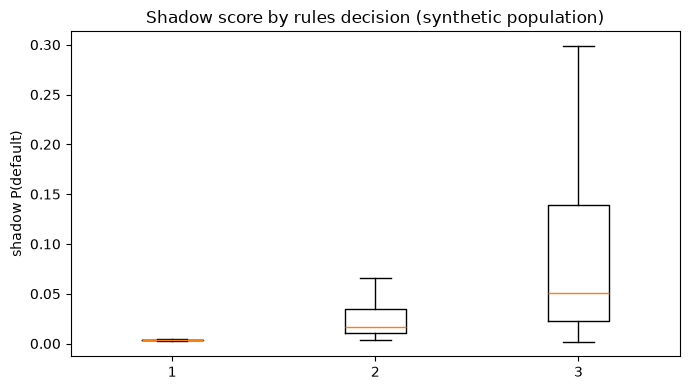

mean shadow P(default) by rules decision: {'APPROVE': 0.006, 'MANUAL_REVIEW': 0.042, 'DECLINE': 0.166}


In [28]:
pop2 = pop.copy()
for col, val in {"kvk_active": True, "sanctions_hit": False, "ubo_director_match": True,
                 "bank_psp_recon_delta": 0.03, "negative_balance_pct_90d": 0.0,
                 "requested_amount": 15_000, "requested_tenor_months": 6,
                 "monthly_net_cashflow_avg_6m": 15_000}.items():
    pop2[col] = val
pop2["rules"]  = [underwrite(r)["decision"] for _, r in pop2.iterrows()]
pop2["shadow"] = model.predict_proba(pop2[ML_FEATURES])[:, 1]

order = ["APPROVE", "MANUAL_REVIEW", "DECLINE"]
data  = [pop2.loc[pop2.rules == k, "shadow"].values for k in order]
fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(data, label=order, showfliers=False)
ax.set_ylabel("shadow P(default)")
ax.set_title("Shadow score by rules decision (synthetic population)")
fig.tight_layout()
plt.show()
print("mean shadow P(default) by rules decision:",
      {k: round(float(pop2.loc[pop2.rules == k, "shadow"].mean()), 3) for k in order})

## What this demonstrates

- **Rules decide; ML watches.** Engine A produced every decision above; Engine B only
  logged a probability (`used=False`).
- **Synthetic data.** The model is trained on synthetic outcomes — illustrative; no
  accuracy is claimed until ~200 real loans exist.
- **Global, not per-merchant.** Importances are the model's average behaviour;
  per-application explanation (SHAP) is Phase 3.
- **Same logic as the repo.** This notebook mirrors `policy/credit_policy.py` and
  `models/train_shadow.py`; the Streamlit app and `data/export_demo_json.py` call the
  same functions.

*`Run ▸ Run All Cells` to execute top-to-bottom (≈ a few seconds).*